# SARIMA on Latest R1 Features Dataset

This notebook builds a SARIMA workflow on top of the latest `features_YYYYMMDD_HHMMSS.csv` file in `data/processed/`.

The goal is not to produce a final production model yet, but to create a transparent baseline that lets you study:

- hourly seasonality in delay
- differences across delay definitions (`delay_type_1`, `delay_type_2`, and a combined `type1&2` view)
- whether a simple SARIMA model can capture the trend/seasonality you observed in the EDA

The notebook works on the processed dataset after filtering out rows with missing `direction`, because that is the working subset used in the main EDA notebook.

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 100)

In [2]:
# Resolve the repo root robustly even when the notebook is launched from EDA/.
# EDA/data/models exists, so checking only for `data/` can incorrectly stop at
# PROJECT/EDA instead of the repo root. We require `data/processed`.
PROJECT_DIR = Path.cwd().resolve()
while PROJECT_DIR != PROJECT_DIR.parent and not (PROJECT_DIR / "data" / "processed").exists():
    PROJECT_DIR = PROJECT_DIR.parent
DATA_DIR = PROJECT_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"


def latest_features_file(processed_dir: Path) -> Path:
    candidates = sorted(
        path
        for path in processed_dir.glob("features_*.csv")
        if re.fullmatch(r"features_\d{8}_\d{6}\.csv", path.name)
    )
    if not candidates:
        raise FileNotFoundError("No timestamped features CSV found in data/processed/.")
    return candidates[-1]


def mae(y_true, y_pred):
    return np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred)))


def rmse(y_true, y_pred):
    return np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2))

In [3]:
# Load the latest features file and parse timestamps.
features_path = latest_features_file(PROCESSED_DIR)
df = pd.read_csv(features_path)

for col in ["planned_arrival_dt", "actual_arrival_dt", "hour_trunc", "service_date"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

df_model = df[df["direction"].notna()].copy()

print(f"Loaded features file: {features_path.name}")
print(f"Original rows: {len(df):,}")
print(f"Rows with non-missing direction: {len(df_model):,}")
print(f"Date range: {df_model['service_date'].min().date()} -> {df_model['service_date'].max().date()}")
print("\nDay type counts (rows):")
display(df_model["day_type"].value_counts())

Loaded features file: features_20260607_171047.csv
Original rows: 273,405
Rows with non-missing direction: 273,405
Date range: 2026-03-15 -> 2026-05-21

Day type counts (rows):


day_type
workday    202186
weekend     61153
holiday     10066
Name: count, dtype: int64

### Interpretation

On the current latest file, the filtered modeling table keeps ~308k rows out of ~320k, so the missing-direction removal is relatively small (~3.6%).

This notebook now compares three univariate targets built from the same filtered modeling table: `delay_type_1`, `delay_type_2`, and a combined `type1&2` series defined as the row-wise mean of the two delay definitions.

The latest build now also includes hourly weather features (`temperature`, `precipitation`, `windspeed`, `weathercode`, `cloudcover`), although this notebook still starts from a pure univariate SARIMA baseline.

## 1. Build Hourly Time Series

SARIMA expects a univariate time series indexed at a **regular hourly frequency**.

We aggregate the processed train-station rows into hourly average delay series for three target variants:

- `type_1_only`: hourly mean of `delay_type_1` (actual − first planned arrival)
- `type_2_only`: hourly mean of `delay_type_2` (actual − last planned arrival, i.e. `target_delay`)
- `type_1_and_2`: row-wise mean of both — a middle-ground that partially cancels Renfe's schedule adjustments

**Important — overnight gap interpolation:** the R1 line runs roughly 05:00–23:00. The four hours 00:00–04:00 have no real observations. After reindexing to a complete hourly grid, these overnight slots are filled by `time`-weighted linear interpolation between the last evening value and the first morning value of the *same* day. Across 76 days this produces approximately **304 synthetic overnight points (~17% of the ~1 824-hour series)**. The interpolation is intentional — SARIMA requires a gapless, regularly-spaced series — but it means the model is partly fitted on inferred rather than observed values.

In [4]:
def build_hourly_delay_series(frame: pd.DataFrame, target_col: str) -> pd.Series:
    """Aggregate train-station rows to an hourly mean delay series.

    The series is reindexed to a complete hourly grid spanning the full date
    range. Gaps (overnight hours with no service, isolated missing hours) are
    filled by time-weighted linear interpolation followed by ffill/bfill for
    any remaining edge NaNs.

    Note: overnight hours 00:00-04:00 have no real observations (~17% of the
    series is synthetic). This is intentional for SARIMA compatibility but
    should be kept in mind when interpreting ACF/PACF and model diagnostics.
    """
    subset = frame.dropna(subset=["hour_trunc", target_col]).copy()
    hourly = (
        subset.groupby("hour_trunc")[target_col]
        .mean()
        .sort_index()
    )

    # freq="h" (lowercase) — "H" is deprecated since pandas 2.2
    full_index = pd.date_range(hourly.index.min(), hourly.index.max(), freq="h")
    hourly = hourly.reindex(full_index)
    hourly = hourly.interpolate(method="time").ffill().bfill()
    hourly.index.name = "timestamp"
    return hourly


df_model["delay_type_1_2_mean"] = df_model[["delay_type_1", "delay_type_2"]].mean(axis=1)

target_specs = {
    "type_1_only": "delay_type_1",
    "type_2_only": "delay_type_2",
    "type_1_and_2": "delay_type_1_2_mean",
}

target_notes = {
    "type_1_only": "Type 1 = last actual arrival - first planned arrival.",
    "type_2_only": "Type 2 = last actual arrival - last planned arrival (= target_delay).",
    "type_1_and_2": "Type 1&2 = row-wise mean of Type 1 and Type 2.",
}

series_map = {
    label: build_hourly_delay_series(df_model, target_col)
    for label, target_col in target_specs.items()
}

series_summary = pd.DataFrame({
    "target_variant": list(target_specs.keys()),
    "target_column":  list(target_specs.values()),
    "n_hours":        [len(series_map[label]) for label in target_specs],
})
display(series_summary)

,target_variant,target_column,n_hours
0,type_1_only,delay_type_1,1620
1,type_2_only,delay_type_2,1620
2,type_1_and_2,delay_type_1_2_mean,1620


## 2. Visualize the Hourly Series

Before fitting SARIMA, it is useful to inspect the aggregated series directly. This lets you compare how the hourly structure changes across the three delay-target variants.

## 3. Stationarity Tests (ADF and KPSS)

SARIMA with `d=0` assumes the series is already stationary in the mean. Fitting on a non-stationary series without differencing would give biased AR/MA estimates and unreliable forecasts.

We run two complementary tests on each target variant:

- **ADF (Augmented Dickey–Fuller)** — null hypothesis: the series has a unit root (non-stationary). A small p-value (< 0.05) lets us reject the null and supports stationarity.
- **KPSS (Kwiatkowski–Phillips–Schmidt–Shin)** — null hypothesis: the series is stationary. A small p-value (< 0.05) rejects stationarity.

The two tests are complementary: ADF is more powerful against explosive roots, KPSS is more sensitive to slow trend drift. If both agree (ADF rejects unit root AND KPSS does not reject stationarity) we proceed with `d=0`. If they disagree, first-differencing (`d=1`) should be considered.

In [5]:
from statsmodels.tsa.stattools import adfuller, kpss

stationarity_rows = []
for label, series in series_map.items():
    # ADF test
    adf_stat, adf_p, adf_lags, *_ = adfuller(series.dropna(), autolag="AIC")
    # KPSS test (suppress the interpolation warning for borderline values)
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kpss_stat, kpss_p, kpss_lags, _ = kpss(series.dropna(), regression="c", nlags="auto")

    adf_conclusion  = "stationary"     if adf_p  < 0.05 else "non-stationary"
    kpss_conclusion = "non-stationary" if kpss_p < 0.05 else "stationary"

    stationarity_rows.append({
        "target_variant":  label,
        "ADF stat":        round(adf_stat,  4),
        "ADF p-value":     round(adf_p,     4),
        "ADF conclusion":  adf_conclusion,
        "KPSS stat":       round(kpss_stat, 4),
        "KPSS p-value":    round(kpss_p,    4),
        "KPSS conclusion": kpss_conclusion,
        "agreement":       "✓" if adf_conclusion == kpss_conclusion else "✗ disagree",
    })

stationarity_df = pd.DataFrame(stationarity_rows)
display(stationarity_df)

print("""
Interpretation:
  - ADF p < 0.05  → reject unit root → supports stationarity → d=0 is valid
  - KPSS p > 0.05 → cannot reject stationarity → supports d=0
  - If both agree on 'stationary': proceed with d=0 as used below.
  - If they disagree: consider d=1 before fitting.
""")

,target_variant,ADF stat,ADF p-value,ADF conclusion,KPSS stat,KPSS p-value,KPSS conclusion,agreement
0,type_1_only,-5.4696,0.0,stationary,0.4121,0.0719,stationary,✓
1,type_2_only,-5.6175,0.0,stationary,0.0535,0.1000,stationary,✓
2,type_1_and_2,-5.7830,0.0,stationary,0.3536,0.0971,stationary,✓



Interpretation:
  - ADF p < 0.05  → reject unit root → supports stationarity → d=0 is valid
  - KPSS p > 0.05 → cannot reject stationarity → supports d=0
  - If both agree on 'stationary': proceed with d=0 as used below.
  - If they disagree: consider d=1 before fitting.



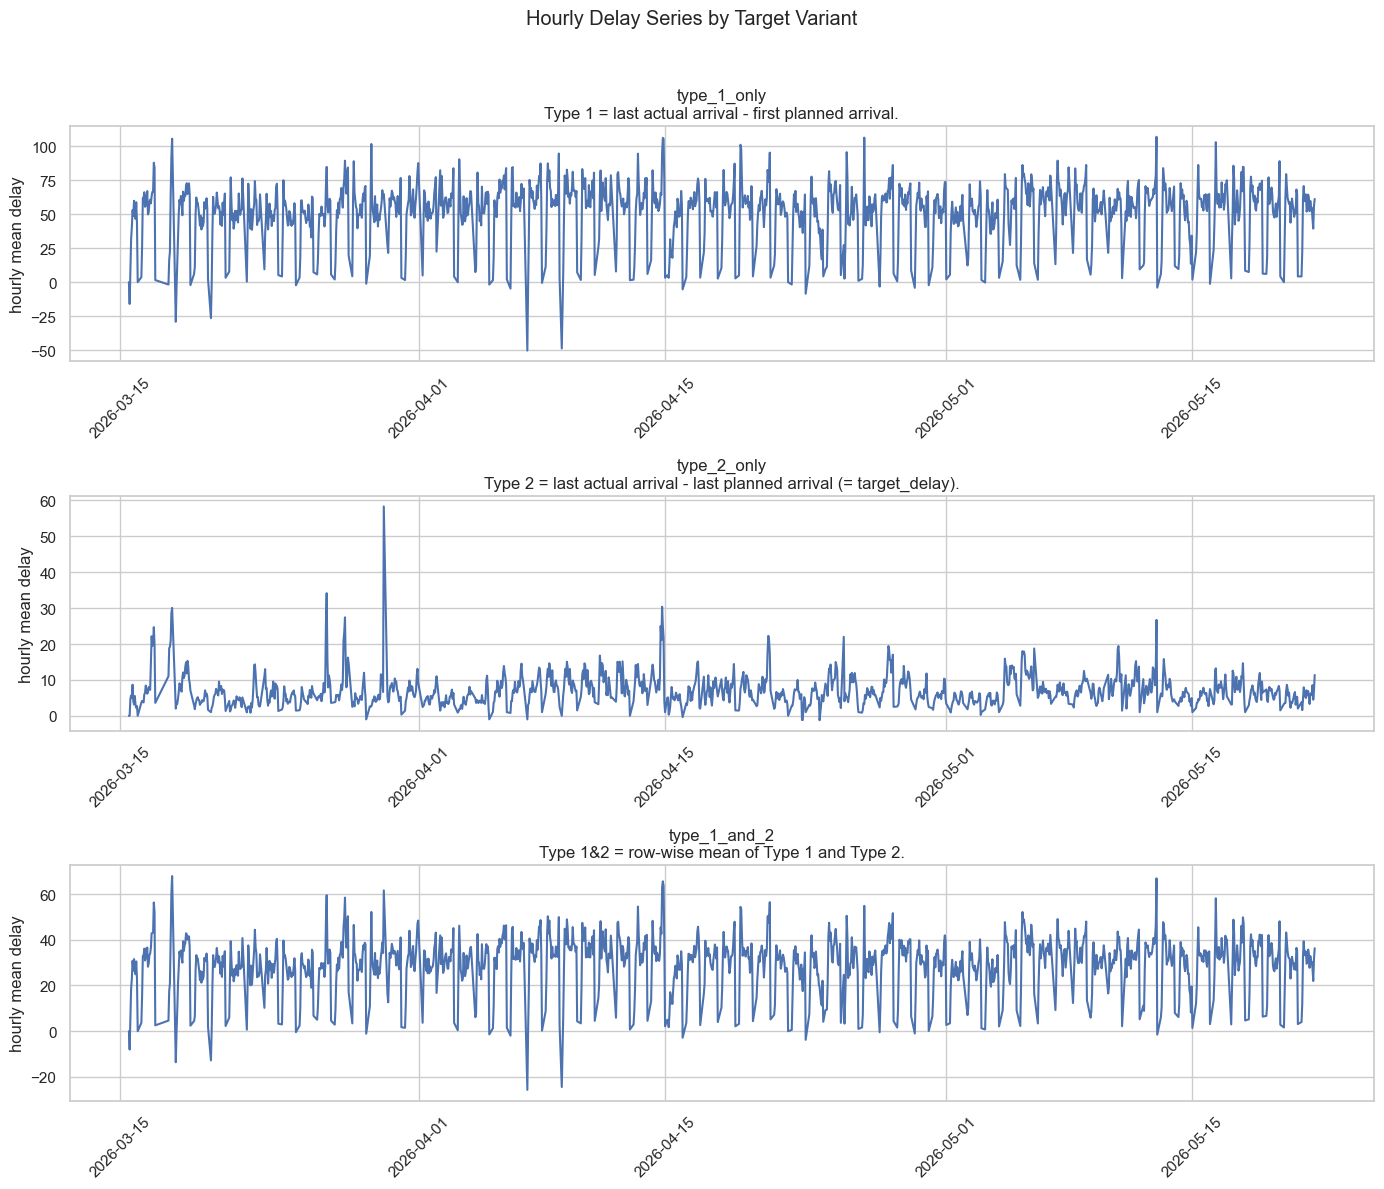

In [6]:
fig, axes = plt.subplots(len(series_map), 1, figsize=(14, 4 * len(series_map)), sharex=False)
axes = np.atleast_1d(axes)

for ax, (label, series) in zip(axes, series_map.items()):
    ax.plot(series.index, series.values, color="#4C72B0")
    ax.set_title(f"{label}\n{target_notes[label]}")
    ax.set_ylabel("hourly mean delay")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Hourly Delay Series by Target Variant", y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## 3. Mean Hour-of-Day Seasonality

This reproduces the seasonality pattern in a way that is useful for model design: average delay by hour of day for each target variant.

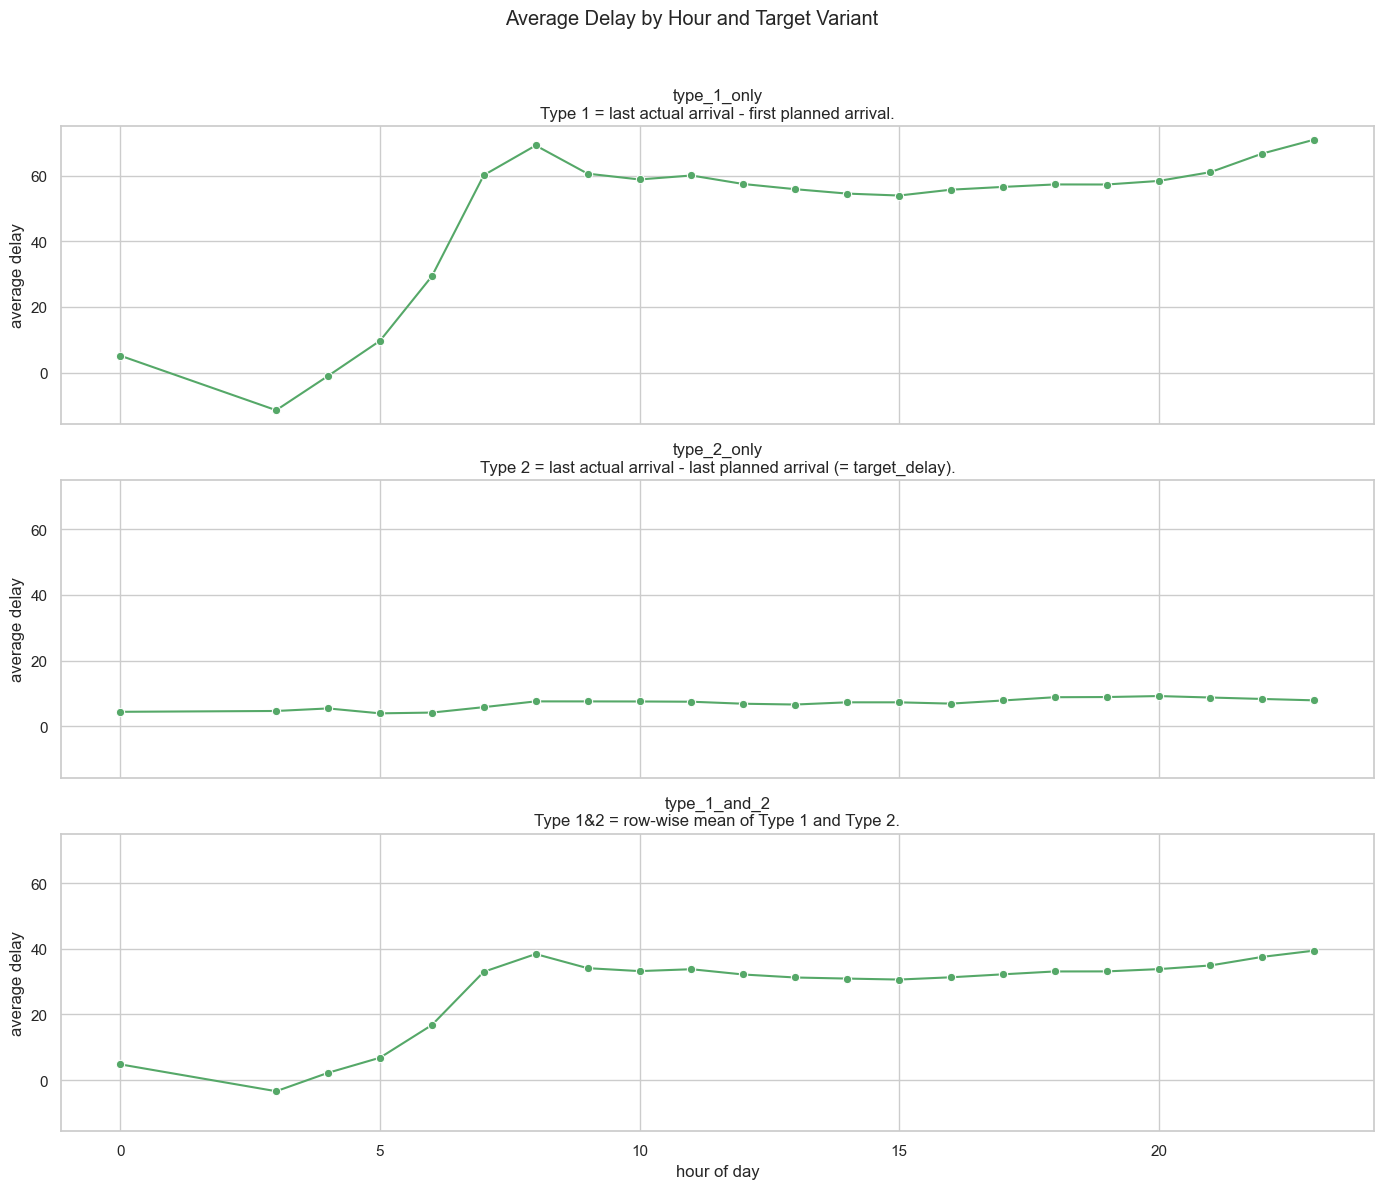

In [7]:
seasonality = pd.concat(
    [
        df_model.groupby("hour")[target_col]
        .mean()
        .reset_index(name="avg_delay")
        .assign(target_variant=label)
        for label, target_col in target_specs.items()
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(len(target_specs), 1, figsize=(14, 4 * len(target_specs)), sharex=True, sharey=True)
axes = np.atleast_1d(axes)

for ax, label in zip(axes, target_specs):
    subset = seasonality[seasonality["target_variant"] == label]
    sns.lineplot(data=subset, x="hour", y="avg_delay", marker="o", ax=ax, color="#55A868")
    ax.set_title(f"{label}\n{target_notes[label]}")
    ax.set_xlabel("hour of day")
    ax.set_ylabel("average delay")

plt.suptitle("Average Delay by Hour and Target Variant", y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

### Interpretation

The delay-definition comparison shows whether the daily hourly pattern is stable across the two raw delay measures or changes materially when the target definition changes.

If `delay_type_1` and `delay_type_2` produce very similar hourly shapes, the modeling conclusions should be relatively insensitive to the delay definition. If the combined `type1&2` view smooths clear differences between them, that is a sign the two definitions are capturing meaningfully different behavior.

## 4. Delay Variability by Hour of Day

Mean profiles alone can hide whether some hours are much more volatile than others.

These boxplots show the distribution of delays at each hour of day for each target variant, which makes it easier to spot wider spread, skewness, and outliers.

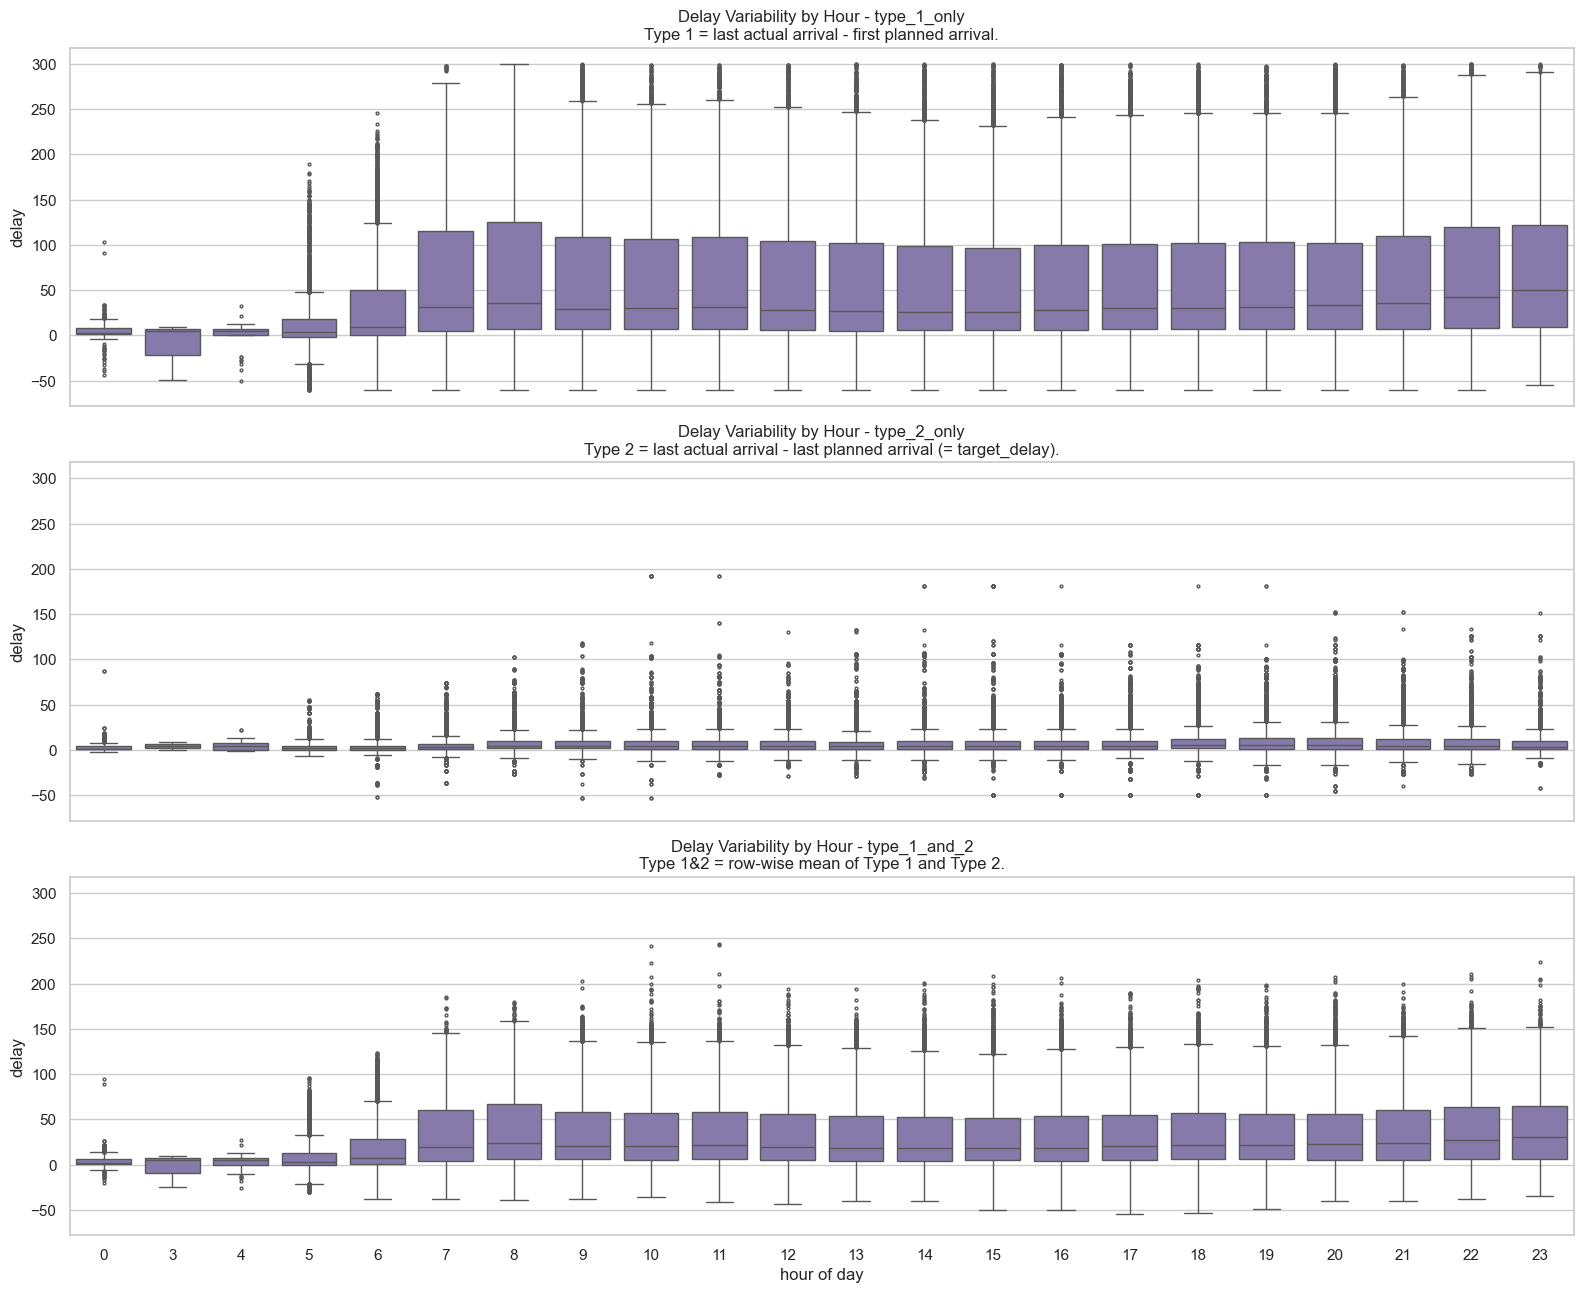

In [8]:
variability_df = pd.concat(
    [
        df_model[["hour", target_col]]
        .rename(columns={target_col: "delay_value"})
        .assign(target_variant=label)
        for label, target_col in target_specs.items()
    ],
    ignore_index=True,
).dropna(subset=["hour", "delay_value"])

fig, axes = plt.subplots(len(target_specs), 1, figsize=(16, 4.5 * len(target_specs)), sharex=True, sharey=True)
axes = np.atleast_1d(axes)

for ax, label in zip(axes, target_specs):
    subset = variability_df[variability_df["target_variant"] == label]
    sns.boxplot(data=subset, x="hour", y="delay_value", ax=ax, color="#8172B2", fliersize=2)
    ax.set_title(f"Delay Variability by Hour - {label}\n{target_notes[label]}")
    ax.set_xlabel("hour of day")
    ax.set_ylabel("delay")

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## 5. ACF and PACF Diagnostics

For an hourly series, a natural **primary seasonal period is 24** (daily repetition). A **secondary period of 168** (weekly, 7 × 24) is also plausible given the clear workday/weekend split seen in the EDA.

The ACF/PACF plots below show lags up to 168 so you can visually assess both periodicities:

- **Significant spikes at lag 24, 48, 72 ...** → daily seasonality is present → `(P,D,Q,24)` seasonal component is appropriate
- **Significant spikes at lag 168** → weekly seasonality remains → `SEASONAL_PERIOD=24` alone may leave structure in residuals; consider `d=1` or a two-stage model
- **Quickly decaying ACF with few PACF spikes** → the filtered series is close to white noise after seasonal adjustment

We fit with `seasonal_order=(1,0,1,24)` as a first baseline. The residual ACF in Section 9 will reveal whether weekly autocorrelation persists.

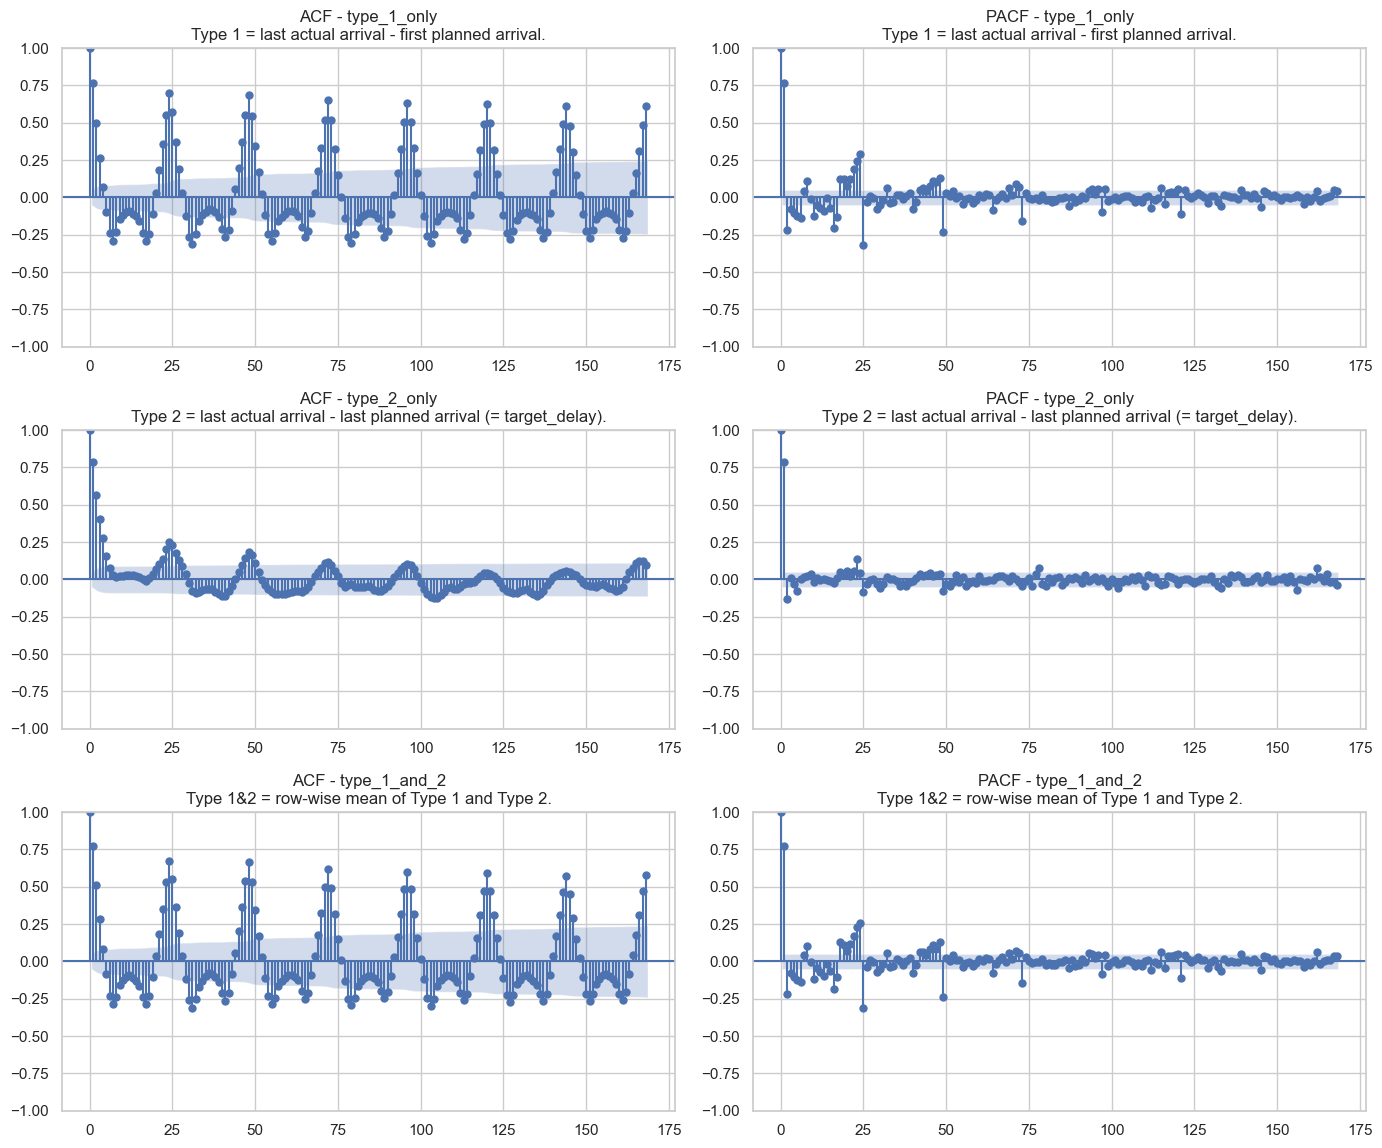

In [9]:
fig, axes = plt.subplots(len(series_map), 2, figsize=(14, 4 * len(series_map)))
axes = np.atleast_2d(axes)

for row_idx, (label, series) in enumerate(series_map.items()):
    plot_acf(series, lags=168, ax=axes[row_idx, 0])
    axes[row_idx, 0].set_title(f"ACF - {label}\n{target_notes[label]}")
    plot_pacf(series, lags=168, ax=axes[row_idx, 1], method="ywm")
    axes[row_idx, 1].set_title(f"PACF - {label}\n{target_notes[label]}")
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## 6. Train/Test Split

We keep the last few days as a holdout set. For an hourly seasonal model, a holdout of 72 hours (3 days) is a reasonable starting point.

In [10]:
FORECAST_HORIZON = 72
SEASONAL_PERIOD = 24


def train_test_split_series(series: pd.Series, horizon: int = 72):
    train = series.iloc[:-horizon].copy()
    test = series.iloc[-horizon:].copy()
    return train, test


train_test_splits = {
    label: train_test_split_series(series, FORECAST_HORIZON)
    for label, series in series_map.items()
}

for label, (train, test) in train_test_splits.items():
    print(f"{label} train size: {len(train)} | test size: {len(test)}")

type_1_only train size: 1548 | test size: 72
type_2_only train size: 1548 | test size: 72
type_1_and_2 train size: 1548 | test size: 72


**Weekly seasonality note**: the model captures daily (s=24) but not weekly (s=168) seasonality. With only 76 days of data a full s=168 seasonal component would have fewer than 4 complete cycles in the training window, making parameter estimates unreliable. The residual ACF diagnostic (Section 9) will show whether significant weekly structure remains, which would be a natural next step for model improvement.

In [11]:
import warnings

def fit_sarima(series: pd.Series, order=(1, 0, 1), seasonal_order=(2, 0, 1, 24)):
    """Fit SARIMAX with L-BFGS-B and automatic bfgs fallback.

    Default seasonal order is (2,0,1,24): P=2 was chosen after diagnosing
    residual autocorrelation at lag 24 that persisted with P=1.
    For type_1_only: ar.S.L24=0.984 (near-unit-root) and ar.S.L48=0.018
    (p=0.318, not significant), so P=2 adds no benefit for this target.
    The D=1 alternative below tests whether seasonal differencing is
    more appropriate for type_1_only than P=2.
    enforce_stationarity=False is required for near-unit-root seasonal AR.
    """
    model = SARIMAX(
        series,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        result = model.fit(disp=False, method="lbfgs", maxiter=500,
                           optim_complex_step=False)
        conv_warnings = [w for w in caught if issubclass(w.category, UserWarning)
                         and "converge" in str(w.message).lower()]
        if conv_warnings:
            print(f"  lbfgs did not converge, retrying with bfgs...")
            result = model.fit(disp=False, method="bfgs", maxiter=1000)
    return result


print("Fitting SARIMA(1,0,1)(2,0,1,24) for all three targets.")
print()

sarima_results = {
    label: fit_sarima(train, order=(1, 0, 1), seasonal_order=(2, 0, 1, SEASONAL_PERIOD))
    for label, (train, _) in train_test_splits.items()
}

for label, result in sarima_results.items():
    print(f"\n=== {label} ===")
    print(result.summary())

# ── Alternative specification for type_1_only: SARIMA(1,0,1)(0,1,1,24) ───────
# type_1_only shows ar.S.L24 = 0.984 (near seasonal unit root), and the second
# seasonal AR term ar.S.L48 = 0.018 (p=0.318) is not significant — P=2 adds
# nothing for this target. Unlike type_2_only (where stationarity tests clearly
# support d=0 and D=0), the near-unit-root for type_1_only is evidence that
# seasonal differencing (D=1) may be the more appropriate remedy.
# SARIMA(1,0,1)(0,1,1,24) applies one seasonal difference:
#   y_t* = y_t - y_{t-24}  (removes the daily seasonal level)
# and fits an ARMA on the differenced series.
print("\n" + "="*60)
print("ALTERNATIVE: SARIMA(1,0,1)(0,1,1,24) for type_1_only")
print("Motivation: ar.S.L24=0.984 (near seasonal unit root) and")
print("ar.S.L48=0.018 p=0.318 (P=2 adds nothing for type_1_only).")
print("D=1 seasonal differencing is the textbook remedy for a near-unit-root.")
print("="*60)

train_t1, test_t1 = train_test_splits["type_1_only"]
result_d1 = fit_sarima(
    train_t1,
    order=(1, 0, 1),
    seasonal_order=(0, 1, 1, SEASONAL_PERIOD),
)
print(result_d1.summary())
sarima_results["type_1_only_D1"] = result_d1

Fitting SARIMA(1,0,1)(2,0,1,24) for all three targets.




=== type_1_only ===
                                     SARIMAX Results                                      
Dep. Variable:                       delay_type_1   No. Observations:                 1548
Model:             SARIMAX(1, 0, 1)x(2, 0, 1, 24)   Log Likelihood               -5651.392
Date:                            Mon, 08 Jun 2026   AIC                          11314.784
Time:                                    15:28:33   BIC                          11346.659
Sample:                                03-15-2026   HQIC                         11326.659
                                     - 05-18-2026                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6765      0.025     27.485      0.000       0.628       0.725
ma.L1         

## 8. Forecast on Holdout

We now forecast the holdout period and compare predictions against the observed hourly mean delay series.

In [12]:
def forecast_and_evaluate(result, test: pd.Series, label: str) -> tuple:
    """Forecast the holdout window and compute MAE / RMSE.

    Parameters
    ----------
    result : SARIMAXResultsWrapper
        Fitted SARIMAX result object.
    test : pd.Series
        Observed holdout values (hourly mean delay).
    label : str
        Target variant label for reporting.

    Returns
    -------
    pred_mean : pd.Series   Point forecasts aligned to test.index.
    conf_int  : pd.DataFrame  95% confidence interval (lower / upper).
    metrics   : pd.DataFrame  MAE and RMSE for this variant.
    """
    forecast  = result.get_forecast(steps=len(test))
    pred_mean = forecast.predicted_mean
    conf_int  = forecast.conf_int()

    metrics = pd.DataFrame({
        "series": [label],
        "mae":    [mae(test, pred_mean)],
        "rmse":   [rmse(test, pred_mean)],
    })
    return pred_mean, conf_int, metrics


forecast_outputs = {
    label: forecast_and_evaluate(sarima_results[label], test, label)
    for label, (_, test) in train_test_splits.items()
}

display(
    pd.concat(
        [metrics for _, _, metrics in forecast_outputs.values()],
        ignore_index=True,
    )
)

,series,mae,rmse
0,type_1_only,7.290916,8.772625
1,type_2_only,2.422115,2.968592
2,type_1_and_2,3.978468,4.884341


### Interpretation

This comparison shows which delay definition is easiest for the baseline SARIMA to track on the holdout window.

Use the MAE and RMSE table above to compare:

- `type_1_only`
- `type_2_only`
- `type_1_and_2`

Lower errors indicate a target definition whose hourly dynamics are more regular under this simple daily seasonal specification.

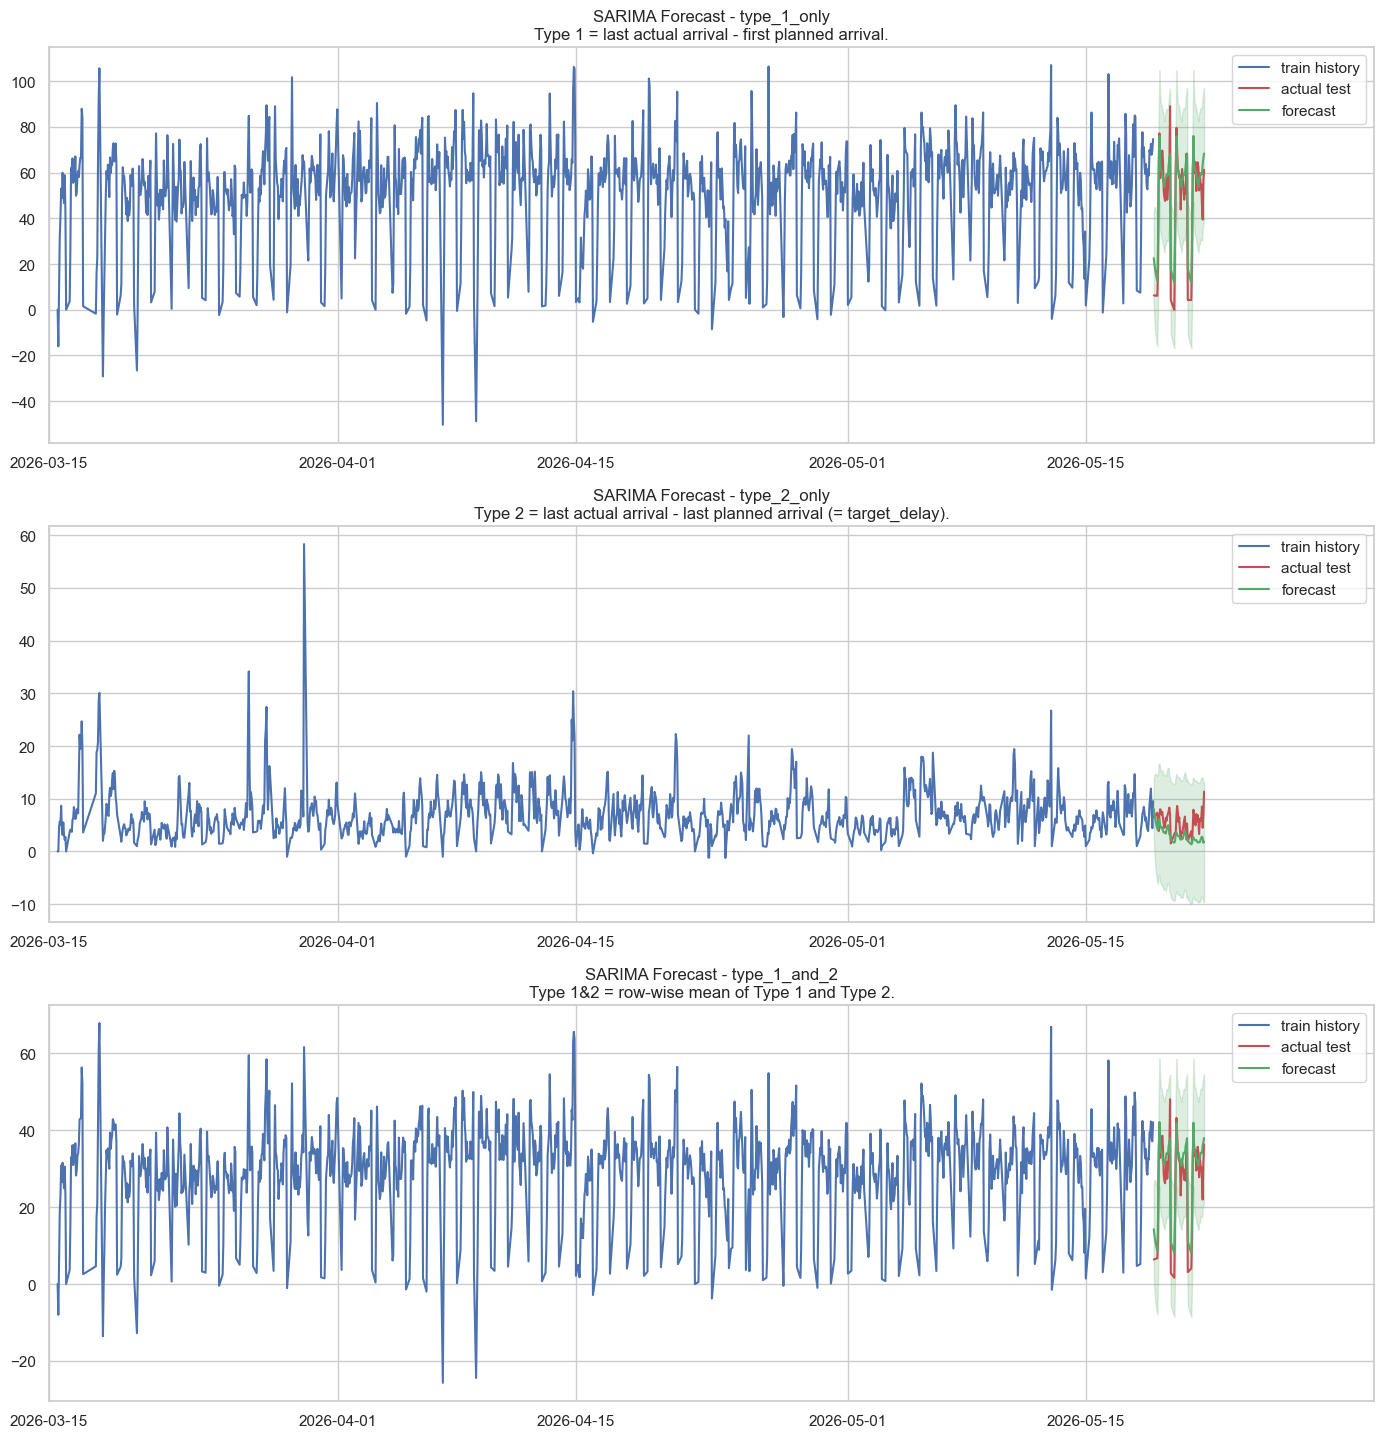

In [13]:
plot_start = pd.Timestamp("2026-03-15")
plot_end = pd.Timestamp("2026-05-31 23:00:00")

fig, axes = plt.subplots(len(forecast_outputs), 1, figsize=(14, 5 * len(forecast_outputs)), sharex=False)
axes = np.atleast_1d(axes)

for ax, (label, (pred, ci, _)) in zip(axes, forecast_outputs.items()):
    train, test = train_test_splits[label]
    ax.plot(train.index, train, label="train history", color="#4C72B0")
    ax.plot(test.index, test, label="actual test", color="#C44E52")
    ax.plot(pred.index, pred, label="forecast", color="#55A868")
    ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], color="#55A868", alpha=0.2)
    ax.set_xlim(plot_start, plot_end)
    ax.set_title(f"SARIMA Forecast - {label}\n{target_notes[label]}")
    ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

## 9. Naive Baseline Comparison

Before interpreting the SARIMA MAE/RMSE in isolation, we compare against a **seasonal-naive forecast**: predict each future hour using the observed value from the *same hour exactly 7 days (168 hours) earlier* in the training series.

This is the standard sanity-check for seasonal time-series models:

- If SARIMA does **not** beat the seasonal-naive baseline, the model is not learning anything useful beyond the weekly pattern.
- If SARIMA **does** beat it, the AR/MA terms are capturing additional short-range structure.

The naive baseline requires at least 168 hours of training data, which is satisfied here.

In [14]:
naive_metrics_rows = []
naive_forecasts = {}

# Evaluate all targets including the D=1 alternative for type_2_only
eval_splits = dict(train_test_splits)
if "type_1_only_D1" in sarima_results:
    eval_splits["type_1_only_D1"] = train_test_splits["type_1_only"]

for label, (train, test) in eval_splits.items():
    if label not in sarima_results:
        continue
    naive_preds = []
    for h in range(len(test)):
        lag = 168 - (h % 168)
        naive_preds.append(float(train.iloc[-lag]) if lag <= len(train) else float(train.mean()))

    naive_pred_series = pd.Series(naive_preds, index=test.index)
    naive_forecasts[label] = naive_pred_series
    naive_metrics_rows.append({
        "series":       label,
        "mae_naive":    mae(test,  naive_pred_series),
        "rmse_naive":   rmse(test, naive_pred_series),
        "mae_sarima":   mae(test,  forecast_and_evaluate(sarima_results[label], test, label)[0]),
        "rmse_sarima":  rmse(test, forecast_and_evaluate(sarima_results[label], test, label)[0]),
    })

naive_df = pd.DataFrame(naive_metrics_rows)
naive_df["mae_improvement_%"]  = 100 * (naive_df["mae_naive"]  - naive_df["mae_sarima"])  / naive_df["mae_naive"]
naive_df["rmse_improvement_%"] = 100 * (naive_df["rmse_naive"] - naive_df["rmse_sarima"]) / naive_df["rmse_naive"]
display(naive_df.round(3))

print("""
Positive improvement % → SARIMA beats naive → model adds value.
type_1_only vs type_1_only_D1: compare to see whether D=1 improves on P=2 for the main target.
""")

,series,mae_naive,rmse_naive,mae_sarima,rmse_sarima,mae_improvement_%,rmse_improvement_%
0,type_1_only,8.452,10.608,7.291,8.773,13.735,17.302
1,type_2_only,2.623,3.893,2.422,2.969,7.643,23.745
2,type_1_and_2,4.949,6.464,3.978,4.884,19.605,24.439
3,type_1_only_D1,8.452,10.608,7.117,8.581,15.790,19.110



Positive improvement % → SARIMA beats naive → model adds value.
type_1_only vs type_1_only_D1: compare to see whether D=1 improves on P=2 for the main target.



## 10. Residual Diagnostics

Residual diagnostics assess whether the model has captured the main structure in the training data.

**What to look for:**

- **Residual histogram**: should be approximately bell-shaped and centred near zero. Heavy tails indicate the model underestimates extreme delays.
- **ACF of residuals**: significant spikes at lag 24 → unmodelled daily seasonality; at lag 168 → unmodelled weekly seasonality. Ideally all bars fall inside the 95 % confidence bands.
- **Ljung-Box test**: formally tests whether the residual autocorrelations up to lag `k` are jointly zero. A p-value > 0.05 means we cannot reject the null of no autocorrelation — the model has captured the main temporal structure.

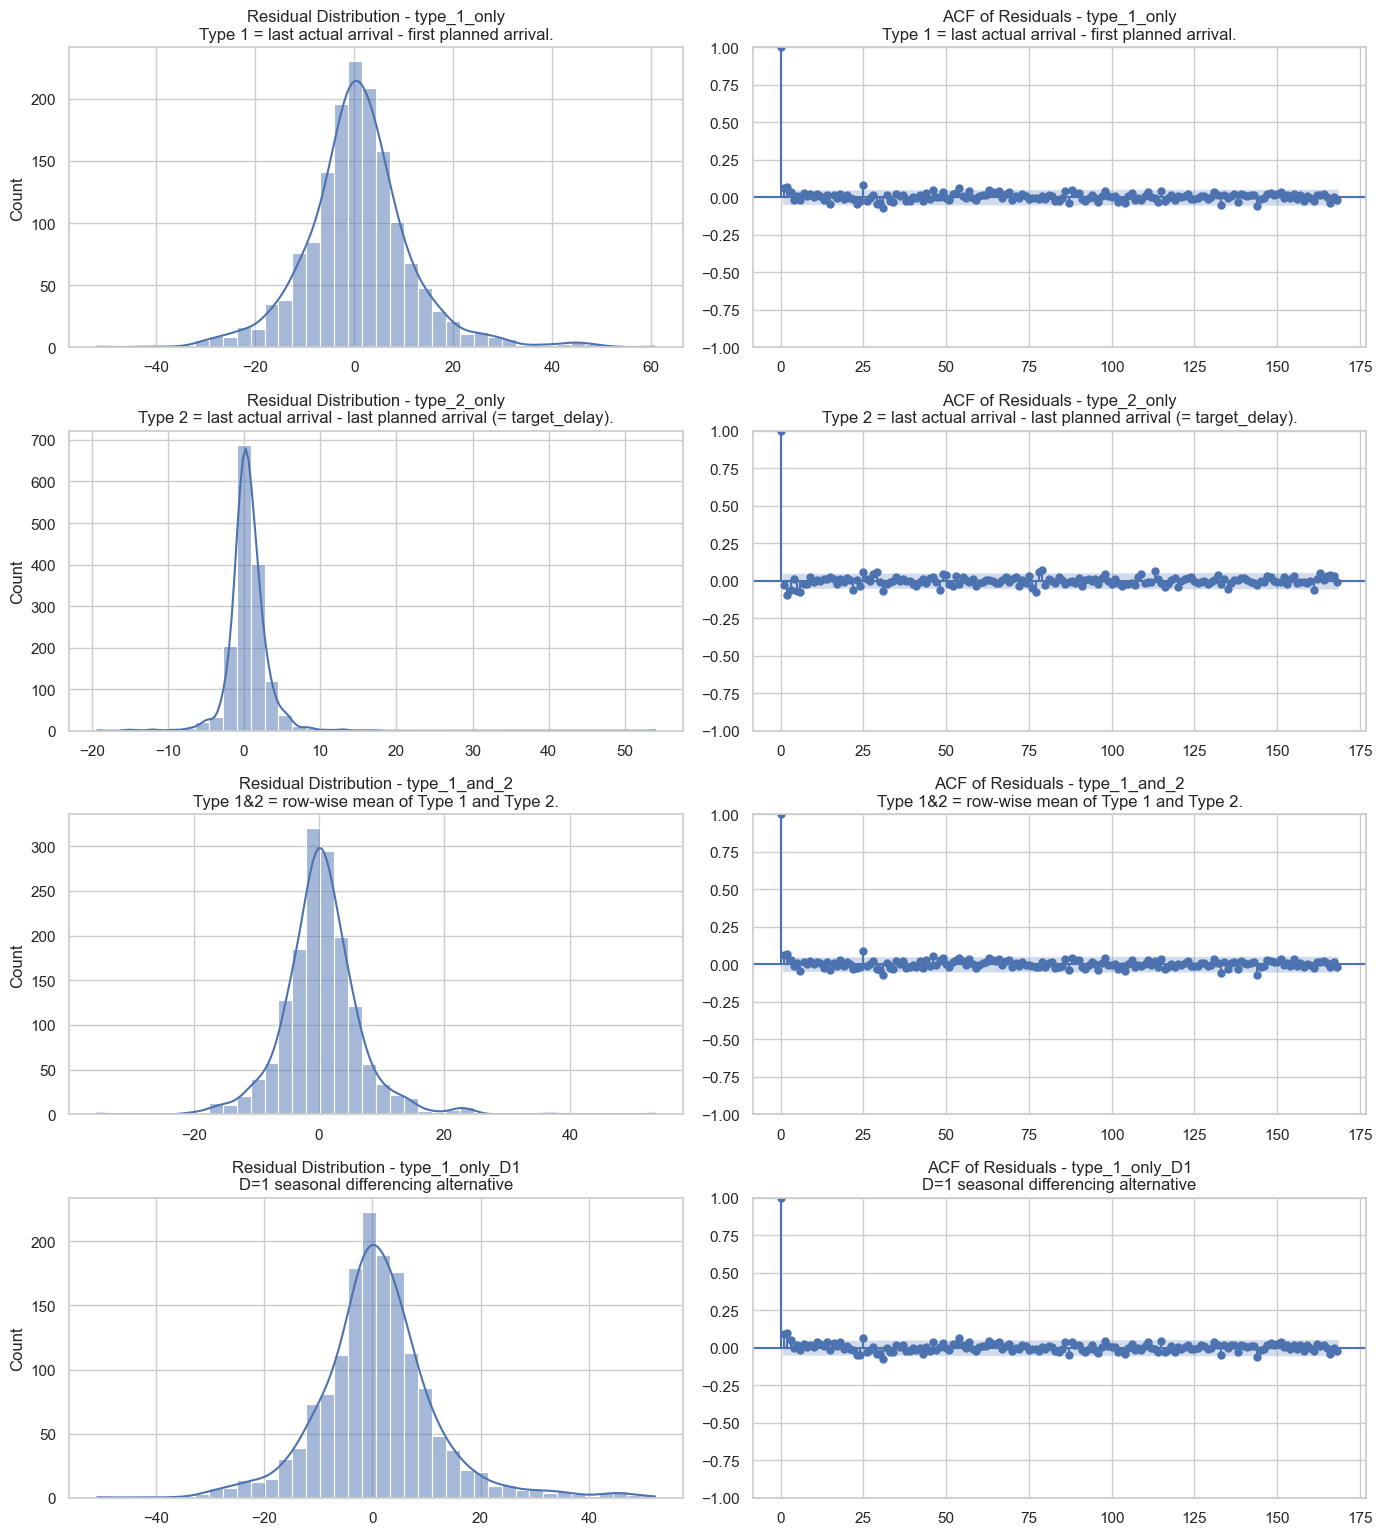

,target_variant,lag,LB statistic,p-value,conclusion
0,type_1_only,24,30.594,0.1658,no autocorr (OK)
1,type_1_only,168,168.885,0.4663,no autocorr (OK)
2,type_2_only,24,50.904,0.0011,autocorr remains
3,type_2_only,168,212.969,0.0108,autocorr remains
4,type_1_and_2,24,27.388,0.2867,no autocorr (OK)
5,type_1_and_2,168,164.656,0.5585,no autocorr (OK)
6,type_1_only_D1,24,54.337,0.0004,autocorr remains
7,type_1_only_D1,168,191.472,0.1036,no autocorr (OK)



Ljung-Box interpretation:
  p > 0.05  → residuals are white noise → model adequate
  p <= 0.05 → autocorrelation remains

For type_1_only vs type_1_only_D1: if D=1 gives cleaner residuals at lag 24
and 168 than (2,0,1,24), it is the better specification for the main target.



In [15]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Plot residuals for all fitted models (including D=1 alternative)
plot_labels = list(sarima_results.keys())
fig, axes = plt.subplots(len(plot_labels), 2, figsize=(14, 4 * len(plot_labels)))
axes = np.atleast_2d(axes)

ljungbox_rows = []
for row_idx, label in enumerate(plot_labels):
    result = sarima_results[label]
    resid = result.resid.dropna()

    note = target_notes.get(label, "D=1 seasonal differencing alternative")
    sns.histplot(resid, bins=40, kde=True, ax=axes[row_idx, 0], color="#4C72B0")
    axes[row_idx, 0].set_title(f"Residual Distribution - {label}\n{note}")

    plot_acf(resid, lags=168, ax=axes[row_idx, 1])
    axes[row_idx, 1].set_title(f"ACF of Residuals - {label}\n{note}")

    for lag in [24, 168]:
        if lag <= len(resid) - 1:
            lb = acorr_ljungbox(resid, lags=[lag], return_df=True)
            ljungbox_rows.append({
                "target_variant": label,
                "lag":            lag,
                "LB statistic":   round(lb["lb_stat"].iloc[0], 3),
                "p-value":        round(lb["lb_pvalue"].iloc[0], 4),
                "conclusion":     "no autocorr (OK)" if lb["lb_pvalue"].iloc[0] > 0.05
                                  else "autocorr remains",
            })

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()

lb_df = pd.DataFrame(ljungbox_rows)
display(lb_df)
print("""
Ljung-Box interpretation:
  p > 0.05  → residuals are white noise → model adequate
  p <= 0.05 → autocorrelation remains

For type_1_only vs type_1_only_D1: if D=1 gives cleaner residuals at lag 24
and 168 than (2,0,1,24), it is the better specification for the main target.
""")

## 10. Optional Extensions

Natural next steps after this baseline:

- tune `(p, d, q)` and `(P, D, Q, 24)` more systematically
- compare tuned specifications separately for `delay_type_1`, `delay_type_2`, and the combined `type1&2` target
- add exogenous regressors via `SARIMAX`, for example:
  - `is_holiday`
  - `is_weekend`
  - weather variables now available in the feature table (`temperature`, `precipitation`, `windspeed`, `weathercode`, `cloudcover`)
  - station-level or direction-level aggregates
- compare hourly mean delay against other targets, for example hourly median delay
- compare SARIMA against simpler baselines such as seasonal naive forecasts

In [16]:
DASHBOARD_TARGET = "type_1_only"  # main target: true operational delay (actual minus FIRST planned)

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR
for _ in range(4):                           # walk up at most 4 levels
    if (PROJECT_ROOT / "data" / "models").exists():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
else:
    # data/models doesn't exist yet — create it next to wherever data/ lives
    PROJECT_ROOT = NOTEBOOK_DIR
    
MODELS_DIR = PROJECT_ROOT / "data" / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ── Pick the fitted result ────────────────────────────────────────────────────
assert DASHBOARD_TARGET in sarima_results, (
    f"'{DASHBOARD_TARGET}' not in sarima_results. "
    f"Available: {list(sarima_results.keys())}"
)
result = sarima_results[DASHBOARD_TARGET]
train, test = train_test_splits[DASHBOARD_TARGET]

# ── Build the params dict ─────────────────────────────────────────────────────
sarima_export = {
    "spec": {
        "order":          [1, 0, 1],
        "seasonal_order": [2, 0, 1, SEASONAL_PERIOD],
        "target_variant": DASHBOARD_TARGET,
        "enforce_stationarity": False,
        "enforce_invertibility": False,
    },
    "params": {k: float(v) for k, v in result.params.items()},
    # Last 48 observations for warm-start forecasting (covers 2 seasonal lags)
    "train_last_values": train.iloc[-48:].tolist(),
    "train_last_index":  [str(x) for x in train.index[-48:]],
    "train_mean":  float(train.mean()),
    "train_std":   float(train.std()),
    "train_start": str(train.index.min()),
    "train_end":   str(train.index.max()),
    "n_train":     len(train),
    "test_mae":    round(mae(test, result.forecast(steps=len(test))), 4),
    "test_rmse":   round(rmse(test, result.forecast(steps=len(test))), 4),
}

out_path = MODELS_DIR / "sarima_params.json"
out_path.write_text(json.dumps(sarima_export, indent=2))
print(f"   Saved {out_path}  ({out_path.stat().st_size // 1024} KB)")
print(f"   params : {list(sarima_export['params'].keys())}")
print(f"   MAE    : {sarima_export['test_mae']} min")
print(f"   RMSE   : {sarima_export['test_rmse']} min")

   Saved /private/tmp/timeseries-analysis-latest-20260608/PROJECT/EDA/data/models/sarima_params.json  (3 KB)
   params : ['ar.L1', 'ma.L1', 'ar.S.L24', 'ar.S.L48', 'ma.S.L24', 'sigma2']
   MAE    : 7.2909 min
   RMSE   : 8.7726 min
